<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install pykrx koreanize-matplotlib

In [ ]:
# 삼성전자 주가 추이 시각화
from pykrx import stock
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

In [ ]:
# 삼성전자 종목 코드(ticker)
# 현대자동차 주가 추가
samsung_ticker = "005930"
hyundai_ticker = "005380"

samsung_df = stock.get_market_ohlcv_by_date("20250101",
                                            "20260331",
                                            samsung_ticker)
hyundai_df = stock.get_market_ohlcv_by_date("20250101",
                                                "20260331",
                                                hyundai_ticker)

# samsung_df.head()
# samsung_df.tail()


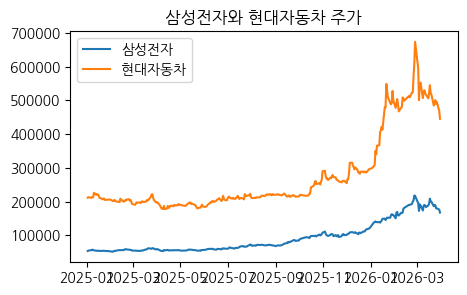

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(samsung_df.index, samsung_df["종가"], label="삼성전자")
plt.plot(hyundai_df.index, hyundai_df["종가"], label="현대자동차")
plt.legend()
plt.title("삼성전자와 현대자동차 주가")
plt.show()

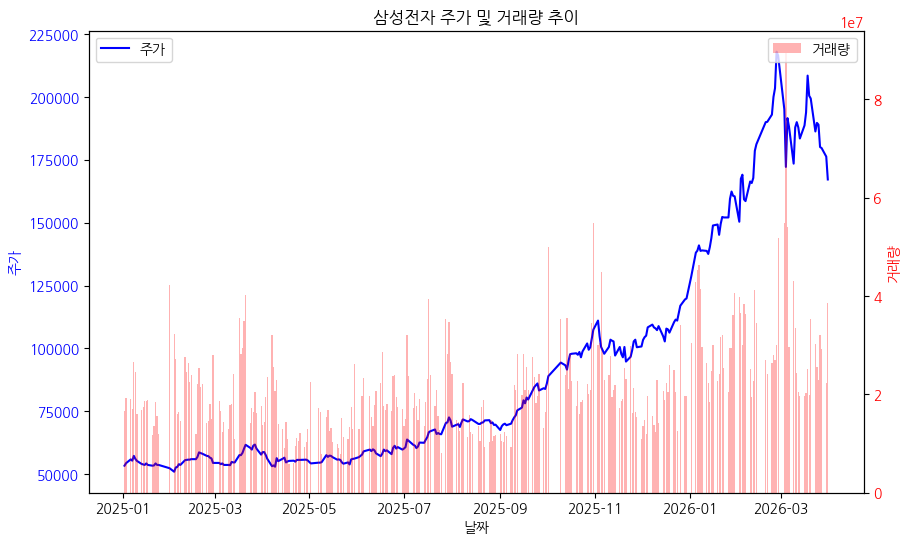

In [ ]:
# 삼성전자 주가 추이 & 거래량 추이
# 왼쪽 세로축은 주가(선그래프), 오른쪽 세로축은 거래량(바그래프)

fig, ax1 = plt.subplots(figsize=(10, 6))

# 주가 (왼쪽 y축)
ax1.plot(samsung_df.index, samsung_df["종가"], color='blue', label='주가')
ax1.set_xlabel('날짜')
ax1.set_ylabel('주가', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# 거래량 (오른쪽 y축)
ax2 = ax1.twinx()
ax2.bar(samsung_df.index, samsung_df["거래량"], color='red', alpha=0.3, label='거래량')
ax2.set_ylabel('거래량', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('삼성전자 주가 및 거래량 추이')
plt.show()

# 회귀분석(Regression)

- 인공지능/계량경제학의 알파며 오메가다.
- regression to the mediocrity (평범, 평균) 평균으로 회귀
- mean-reversion property



In [ ]:
import pandas as pd

galton_df = pd.read_csv('/content/galton.csv')

# galton_df.describe()

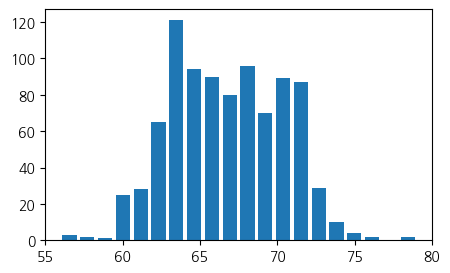

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(5, 3))
plt.hist(galton_df['height'], bins='auto', rwidth=0.8)
plt.show()

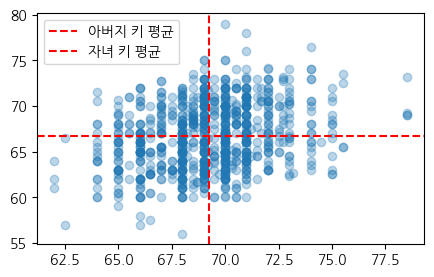

In [ ]:
# 가로축: 아빠의 키, 세로축: 자녀의 키

plt.figure(figsize=(5, 3))
plt.scatter(galton_df['father'], galton_df['height'], alpha=0.3)

# 아버지 키 평균선 추가
plt.axvline(galton_df['father'].mean(), color='red', linestyle='--', label='아버지 키 평균')
# 자녀 키 평균선 추가
plt.axhline(galton_df['height'].mean(), color='red', linestyle='--', label='자녀 키 평균')

plt.legend()
plt.show()

- 데이터를 잘 묘사할 수 있는 관계는 조건부 평균
$$
E[Y | X = x]  = a + b x
$$

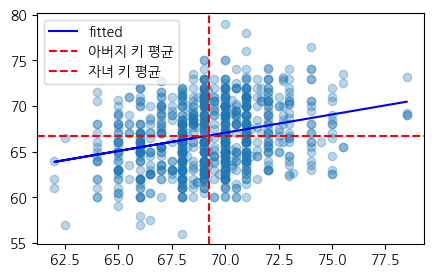

In [ ]:
from scipy import stats

slope, intercept = stats.linregress(galton_df['father'], galton_df['height'])[:2]


plt.figure(figsize=(5, 3))
plt.scatter(galton_df['father'], galton_df['height'], alpha=0.3)

plt.plot(galton_df['father'], slope*galton_df['father']+ intercept,
         color = 'blue', label = 'fitted')

# 아버지 키 평균선 추가
plt.axvline(galton_df['father'].mean(), color='red', linestyle='--', label='아버지 키 평균')
# 자녀 키 평균선 추가
plt.axhline(galton_df['height'].mean(), color='red', linestyle='--', label='자녀 키 평균')

plt.legend()
plt.show()

- 어떻게 저 직선을 추정하느냐?
- (Ordinary) Least Square 추정(OLS 추정)


